In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns
from matplotlib.lines import Line2D

In [4]:
max='../data/master/df_max.xlsx'
mean='../data/master/df_mean.xlsx'

In [7]:
df_max = pd.read_excel(max)
df_mean = pd.read_excel(mean)

In [21]:
df_max_boxcox=pd.read_csv('../data/master/intact_max_boxcox.csv')
df_mean_boxcox=pd.read_csv('../data/master/intact_mean_boxcox.csv')

In [22]:
df_max_yeojohnson=pd.read_csv('../data/master/intact_max_yeojohnson.csv')
df_mean_yeojohnson=pd.read_csv('../data/master/intact_mean_yeojohnson.csv')

In [87]:
FEATURES = ['VAR_STD','Range','Energy','Peak_to_Peak','VAR','Max','MNF','SSC']

# Comparación de estadísticas antes/después de cada transformación.

In [1]:
from scipy.stats import skew, kurtosis

def calcular_sesgo(df, features=None, n_channels=8,
                   group_by=None, pooled=False,
                   robust=False, min_n=30, extra_stats=True):
    """
    Calcula el sesgo de features EMG por canal (o agregando canales).

    group_by : lista de columnas para segmentar, ej. ['origin_db'] o
               ['origin_db','stimulus']. None = todo el dataset junto.
    pooled   : True agrupa los 8 canales en una sola distribución por feature.
    robust   : True añade el sesgo de Bowley (basado en cuartiles), insensible
               a colas extremas. Útil cuando Fisher-Pearson se dispara.
    min_n    : mínimo de observaciones para reportar; por debajo devuelve NaN.
    """
    if features is None:
        features = ['VAR_STD','Range','Energy','Peak_to_Peak','VAR','Max','MNF','SSC']

    def _stats(v):
        v = v[np.isfinite(v)]
        n = v.size
        if n < min_n:
            return dict(n=n, skew=np.nan)
        d = dict(n=n, skew=skew(v, bias=False))
        if extra_stats:
            d.update(mean=v.mean(), median=np.median(v), std=v.std(ddof=1),
                     kurtosis=kurtosis(v, bias=False),
                     pct_zeros=(v == 0).mean())
        if robust:
            q1, q2, q3 = np.percentile(v, [25, 50, 75])
            iqr = q3 - q1
            d['skew_bowley'] = (q3 + q1 - 2*q2) / iqr if iqr > 0 else np.nan
        return d

    grupos = df.groupby(group_by, dropna=False) if group_by else [((), df)]
    filas = []

    for llave, sub in grupos:
        llave = llave if isinstance(llave, tuple) else (llave,)
        meta = dict(zip(group_by or [], llave))

        for feat in features:
            cols = [f'Channel {ch}_{feat}' for ch in range(1, n_channels+1)]
            cols = [c for c in cols if c in sub.columns]
            if not cols:
                continue

            if pooled:
                filas.append({**meta, 'feature': feat, 'channel': 'all',
                              **_stats(sub[cols].to_numpy(dtype=float).ravel())})
            else:
                for c in cols:
                    ch = int(c.split(' ')[1].split('_')[0])
                    filas.append({**meta, 'feature': feat, 'channel': ch,
                                  **_stats(sub[c].to_numpy(dtype=float))})

    return pd.DataFrame(filas)

In [9]:
calcular_sesgo(df_mean, pooled=True, robust=True, min_n=30)

,feature,channel,n,skew,mean,median,std,kurtosis,pct_zeros,skew_bowley
0,VAR_STD,all,4872,11.940418,1.160633e+06,0.017390,6.878686e+06,201.637401,0.0,0.995356
1,Range,all,4872,5.487950,1.456229e+02,0.127500,5.367750e+02,36.447171,0.0,0.923155
2,Energy,all,4872,11.860882,3.158692e+08,1.509890,1.924174e+09,193.488432,0.0,0.996588
3,Peak_to_Peak,all,4872,5.386145,6.189232e+03,0.517639,2.208453e+04,38.422662,0.0,0.895364
4,VAR,all,4872,20.166882,2.565901e+03,0.000128,1.926913e+04,642.716685,0.0,0.996136
5,Max,all,4872,5.302826,1.128219e+03,1.139535,3.945490e+03,36.354333,0.0,0.925805
6,MNF,all,4872,-0.066548,3.413466e+03,4743.548694,2.670612e+03,-1.409988,0.0,-0.724543
7,SSC,all,4872,0.139183,1.947521e+03,2644.229167,1.594921e+03,-1.119674,0.0,-0.717021


In [8]:
calcular_sesgo(df_max, pooled=True, robust=True, min_n=30)

,feature,channel,n,skew,mean,median,std,kurtosis,pct_zeros,skew_bowley
0,VAR_STD,all,4872,10.021227,2.367078e+06,0.076184,1.314389e+07,134.817074,0.0,0.992371
1,Range,all,4872,5.432682,2.922058e+02,0.350524,1.069021e+03,36.209663,0.0,0.893826
2,Energy,all,4872,10.273500,5.412934e+08,4.972681,3.141864e+09,135.668210,0.0,0.994636
3,Peak_to_Peak,all,4872,5.003262,9.672321e+03,1.442767,3.395955e+04,31.244606,0.0,0.863662
4,VAR,all,4872,31.096750,9.618865e+03,0.000556,8.997700e+04,1379.496438,0.0,0.994219
5,Max,all,4872,5.046777,1.552726e+03,2.406477,5.383333e+03,31.378241,0.0,0.895467
6,MNF,all,4872,-0.050283,3.838957e+03,5333.568089,2.949764e+03,-1.400397,0.0,-0.754383
7,SSC,all,4872,0.160227,2.191430e+03,2940.208333,1.754609e+03,-1.102794,0.0,-0.725236


In [85]:
def comparar_agregadores(dfs, features, n_channels=8, col_stim='stimulus'):
    """
    dfs : {'Media': df_mean, 'Máximo': df_max}
    Devuelve eta² por feature × canal × enfoque: qué fracción de la varianza
    total explica el estímulo. Mayor = los agarres se distinguen mejor.
    """
    filas = []
    for nombre, df in dfs.items():
        for feat in features:
            for ch in range(1, n_channels+1):
                col = f'Channel {ch}_{feat}'
                if col not in df.columns:
                    continue
                g = [x[col].dropna().to_numpy() for _, x in df.groupby(col_stim)]
                g = [x for x in g if len(x) > 2]
                if len(g) < 2:
                    continue
                todos = np.concatenate(g); gm = todos.mean()
                ss_b = sum(len(x)*(x.mean()-gm)**2 for x in g)
                ss_t = ((todos-gm)**2).sum()
                filas.append({'enfoque': nombre, 'Feature': feat, 'Channel': ch,
                              'eta2': ss_b/ss_t if ss_t > 0 else np.nan,
                              'cv': todos.std()/abs(gm) if gm else np.nan})
    return pd.DataFrame(filas)


def plot_agregadores(df_sep, features, metrica='eta2'):
    colors = {'Media':'#3d5a99', 'Máximo':'#c1663d'}
    enfoques = [e for e in colors if e in set(df_sep.enfoque)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7),
                                   gridspec_kw={'width_ratios':[1.4, 1]})

    # barras por feature
    x = np.arange(len(features)); w = .38
    for j, e in enumerate(enfoques):
        vals = [df_sep.loc[(df_sep.Feature==f) & (df_sep.enfoque==e),
                           metrica].median() for f in features]
        b = ax1.bar(x + (j-.5)*w, vals, w*.92, color=colors[e],
                    edgecolor='white', linewidth=1.2, zorder=3, label=e)
        ax1.bar_label(b, fmt='%.3f', fontsize=10, fontweight='bold', padding=3)
    ax1.set_xticks(x); ax1.set_xticklabels(features, rotation=30, ha='right', fontsize=12)
    ax1.set_ylabel('η²  (varianza explicada por el estímulo)', fontsize=13)
    ax1.set_title('Separabilidad entre agarres por feature',
                  fontweight='bold', fontsize=15)
    ax1.grid(axis='y', alpha=.25, zorder=0); ax1.set_axisbelow(True)
    ax1.legend(fontsize=13, frameon=False)
    for s in ('top','right'): ax1.spines[s].set_visible(False)

    # scatter pareado: cada punto = feature × canal
    w2 = df_sep.pivot_table(index=['Feature','Channel'], columns='enfoque',
                            values=metrica).dropna()
    gana = (w2[enfoques[1]] > w2[enfoques[0]]).mean()
    sns.scatterplot(data=w2.reset_index(), x=enfoques[0], y=enfoques[1],
                    hue='Feature', s=70, alpha=.8, edgecolor='white', ax=ax2)
    lim = (0, max(w2.to_numpy().max()*1.1, .05))
    ax2.plot(lim, lim, 'k--', lw=1.5, zorder=0)
    ax2.set_xlim(lim); ax2.set_ylim(lim); ax2.set_aspect('equal')
    ax2.set_title(f'{enfoques[1]} mejor en {gana:.0%} de los casos',
                  fontweight='bold', fontsize=15)
    ax2.set_xlabel(f'η² — {enfoques[0]}', fontsize=13)
    ax2.set_ylabel(f'η² — {enfoques[1]}', fontsize=13)
    ax2.legend(fontsize=9, loc='upper left', framealpha=.9)
    ax2.grid(alpha=.25)

    fig.suptitle('Media vs Máximo por ventana — ¿cuál conserva mejor la información de agarre?',
                 fontsize=19, fontweight='bold', y=1.01)
    fig.tight_layout(); plt.show()
    return w2

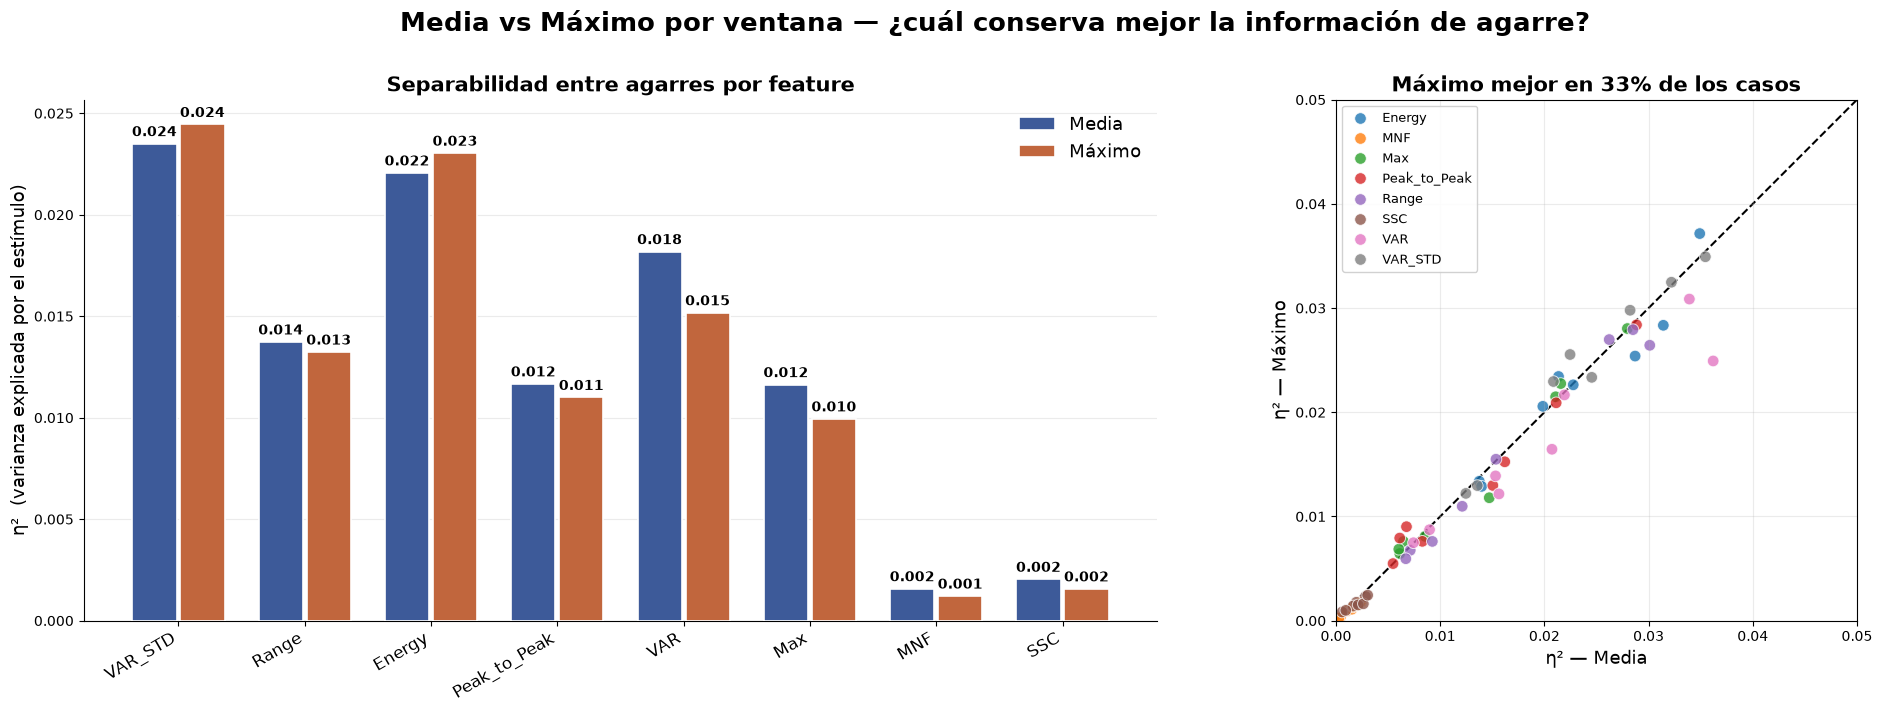

In [86]:
df_sep = comparar_agregadores({'Media': df_mean, 'Máximo': df_max}, FEATURES)
w = plot_agregadores(df_sep, FEATURES)

In [90]:
def plot_correlation_comparison(df_orig, df_trans, features, n_channels=8,
                                nombre_trans='Transformada', tol=1e-6):
    cols = [f'Channel {ch}_{f}' for f in features for ch in range(1, n_channels+1)]
    cols = [c for c in cols if c in df_orig.columns and c in df_trans.columns]

    po, pt = df_orig[cols].corr(), df_trans[cols].corr()
    so, st = df_orig[cols].corr('spearman'), df_trans[cols].corr('spearman')
    mask = np.triu(np.ones_like(po, dtype=bool), k=1)

    # --- chequeo de integridad ---
    d = np.abs((so - st).to_numpy()[mask])
    if np.nanmax(d) > tol:
        print(f'ALERTA: Spearman difiere (máx {np.nanmax(d):.2e}). '
              f'Spearman debe ser invariante a transformaciones monótonas — '
              f'revisa si algún CSV está desactualizado o desalineado.')
    else:
        print(f'Integridad OK: Spearman invariante (máx {np.nanmax(d):.2e}).')

    fig, axes = plt.subplots(2, 2, figsize=(19, 16))
    for ax, (m, t) in zip(axes.flat,
            [(po, f'Pearson — Original'), (pt, f'Pearson — {nombre_trans}'),
             (so, f'Spearman — Original'), (st, f'Spearman — {nombre_trans}')]):
        sns.heatmap(m, cmap='coolwarm', ax=ax, center=0, vmin=-1, vmax=1,
                    square=True, xticklabels=False, yticklabels=False,
                    cbar_kws={'shrink':.7})
        ax.set_title(f'{t}   (|r| medio = {np.abs(m.to_numpy()[mask]).mean():.3f})',
                     fontweight='bold', fontsize=14)

    gap_o = np.abs(so.to_numpy()[mask]).mean() - np.abs(po.to_numpy()[mask]).mean()
    gap_t = np.abs(st.to_numpy()[mask]).mean() - np.abs(pt.to_numpy()[mask]).mean()
    print(f'Brecha Spearman-Pearson:  original {gap_o:+.3f}  →  '
          f'{nombre_trans.lower()} {gap_t:+.3f}')

    fig.suptitle('Correlaciones: Pearson cambia (linealización), Spearman no (invariancia)',
                 fontsize=17, fontweight='bold', y=.995)
    fig.tight_layout(rect=[0,0,1,.97]); plt.show()

In [47]:
def compare_transform_stats(df_original, transformados, variable,
                            n_channels=8, group_by=('Stimulus'), min_n=15,
                            umbral_sesgo=0.1, check_alignment=True):
    """
    df_original  : DataFrame sin transformar
    transformados: dict {'Box-Cox': df_bc, 'Yeo-Johnson': df_yj}
    umbral_sesgo : si |Sesgo_original| < umbral, Pct_cambio_sesgo = NaN
                   (el porcentaje es inestable cuando el sesgo base ~ 0)
    """
    group_by = list(group_by)
    filas = []

    def _sub(df, llave):
        m = np.ones(len(df), dtype=bool)
        for k, v in zip(group_by, llave):
            m &= (df[k] == v).to_numpy()
        return df[m]

    for llave, orig_g in df_original.groupby(group_by, dropna=False):
        llave = llave if isinstance(llave, tuple) else (llave,)
        meta = dict(zip(group_by, llave))

        for ch in range(1, n_channels + 1):
            col = f'Channel {ch}_{variable}'
            if col not in orig_g.columns:
                continue

            o = orig_g[col].dropna()
            s_o = o.skew() if len(o) >= min_n else np.nan
            base = dict(**meta, Channel=ch, Feature=variable)

            # --- fila de referencia ---
            filas.append({**base, 'transformacion': 'Original', 'n': len(o),
                          'Sesgo': s_o, 'Pct_cambio_sesgo': 0.0,
                          'Mejora': pd.NA, 'Cruza_cero': pd.NA,
                          'Media': o.mean(), 'Varianza': o.var()})

            # --- una fila por transformación ---
            for nombre, df_t in transformados.items():
                trans_g = _sub(df_t, llave)
                if check_alignment and len(orig_g) != len(trans_g):
                    raise ValueError(f'{nombre} {meta}: {len(orig_g)} vs {len(trans_g)} filas')
                if col not in trans_g.columns:
                    continue

                t = trans_g[col].dropna()
                s_t = t.skew() if len(t) >= min_n else np.nan

                if np.isfinite(s_o) and np.isfinite(s_t) and abs(s_o) >= umbral_sesgo:
                    pct = (abs(s_t) - abs(s_o)) / abs(s_o) * 100
                    mejora = abs(s_t) < abs(s_o)
                    cruza = np.sign(s_o) != np.sign(s_t)
                else:
                    pct, mejora, cruza = np.nan, pd.NA, pd.NA

                filas.append({**base, 'transformacion': nombre, 'n': len(t),
                              'Sesgo': s_t, 'Pct_cambio_sesgo': pct,
                              'Mejora': mejora, 'Cruza_cero': cruza,
                              'Media': t.mean(), 'Varianza': t.var()})

    cols = group_by + ['Channel', 'Feature', 'transformacion', 'n',
                       'Sesgo', 'Pct_cambio_sesgo', 'Mejora', 'Cruza_cero',
                       'Media', 'Varianza']
    return pd.DataFrame(filas)[cols].round(4)

In [50]:
df_comparacion = pd.concat([
    compare_transform_stats(df_mean,
                            {'Box-Cox': df_mean_boxcox, 'Yeo-Johnson': df_mean_yeojohnson},
                            feat,
                            group_by=('stimulus',),
                            min_n=15)
    for feat in FEATURES
], ignore_index=True)

In [88]:
from matplotlib.colors import LogNorm

def heatmap_sesgo(df_comparacion, features=None, agg='mean',
                  log=True, vmin=None, vmax=None, umbral=0.5,
                  separar=('MNF','SSC'), figsize=None):
    """
    Filas = features, columnas = estímulos, color = |sesgo| agregado.
    log=True : escala de color logarítmica — necesaria porque los valores
               abarcan ~2 órdenes de magnitud entre Original y Box-Cox.
    umbral   : |sesgo| bajo el cual se considera simétrico (marca el texto).
    separar  : features que se dibujan bajo una línea divisoria.
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    if features is not None:
        d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]

    feats = list(features) if features is not None else sorted(set(d.Feature))
    abajo = [f for f in feats if f in (separar or ())]
    arriba = [f for f in feats if f not in abajo]
    feats = arriba + abajo

    pivots = {t: d[d.transformacion == t]
                 .pivot_table(index='Feature', columns='stimulus',
                              values='abs', aggfunc=agg).reindex(feats)
              for t in orden}

    todos = np.concatenate([p.to_numpy().ravel() for p in pivots.values()])
    todos = todos[np.isfinite(todos) & (todos > 0)]
    vmin = vmin or todos.min()*.9
    vmax = vmax or todos.max()*1.1
    norm = LogNorm(vmin=vmin, vmax=vmax) if log else None

    figsize = figsize or (8.5*len(orden), 1.0*len(feats) + 3.2)
    fig, axes = plt.subplots(1, len(orden), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, t in zip(axes, orden):
        p = pivots[t]
        sns.heatmap(p, ax=ax, cmap='RdYlGn_r', norm=norm,
                    vmin=None if log else vmin, vmax=None if log else vmax,
                    annot=True, fmt='.2f', annot_kws={'size': 11, 'weight': 'bold'},
                    linewidths=1.2, linecolor='white',
                    cbar=(ax is axes[-1]), square=False,
                    cbar_kws={'label': f'|Sesgo| ({agg}) — escala log'
                                       if log else f'|Sesgo| ({agg})',
                              'pad': .02, 'aspect': 30} if ax is axes[-1] else None)

        if abajo:
            ax.axhline(len(arriba), color='black', lw=3)

        med = np.nanmedian(p.to_numpy())
        pct_ok = np.nanmean(p.to_numpy() < umbral) * 100
        ax.set_title(f'{t}\nmediana {med:.3f}  ·  {pct_ok:.0f}% bajo {umbral}',
                     fontweight='bold', fontsize=15, pad=12)
        ax.set_xlabel('Estímulo', fontsize=13)
        ax.set_ylabel('')
        ax.tick_params(axis='y', rotation=0, labelsize=12)
        ax.tick_params(axis='x', labelsize=12)

    fig.suptitle('Magnitud del sesgo por feature y estímulo — escala de color común',
                 fontsize=19, fontweight='bold', y=1.0)
    fig.tight_layout(rect=[0, 0, 1, .94], w_pad=2.0)
    plt.show()
    return pivots

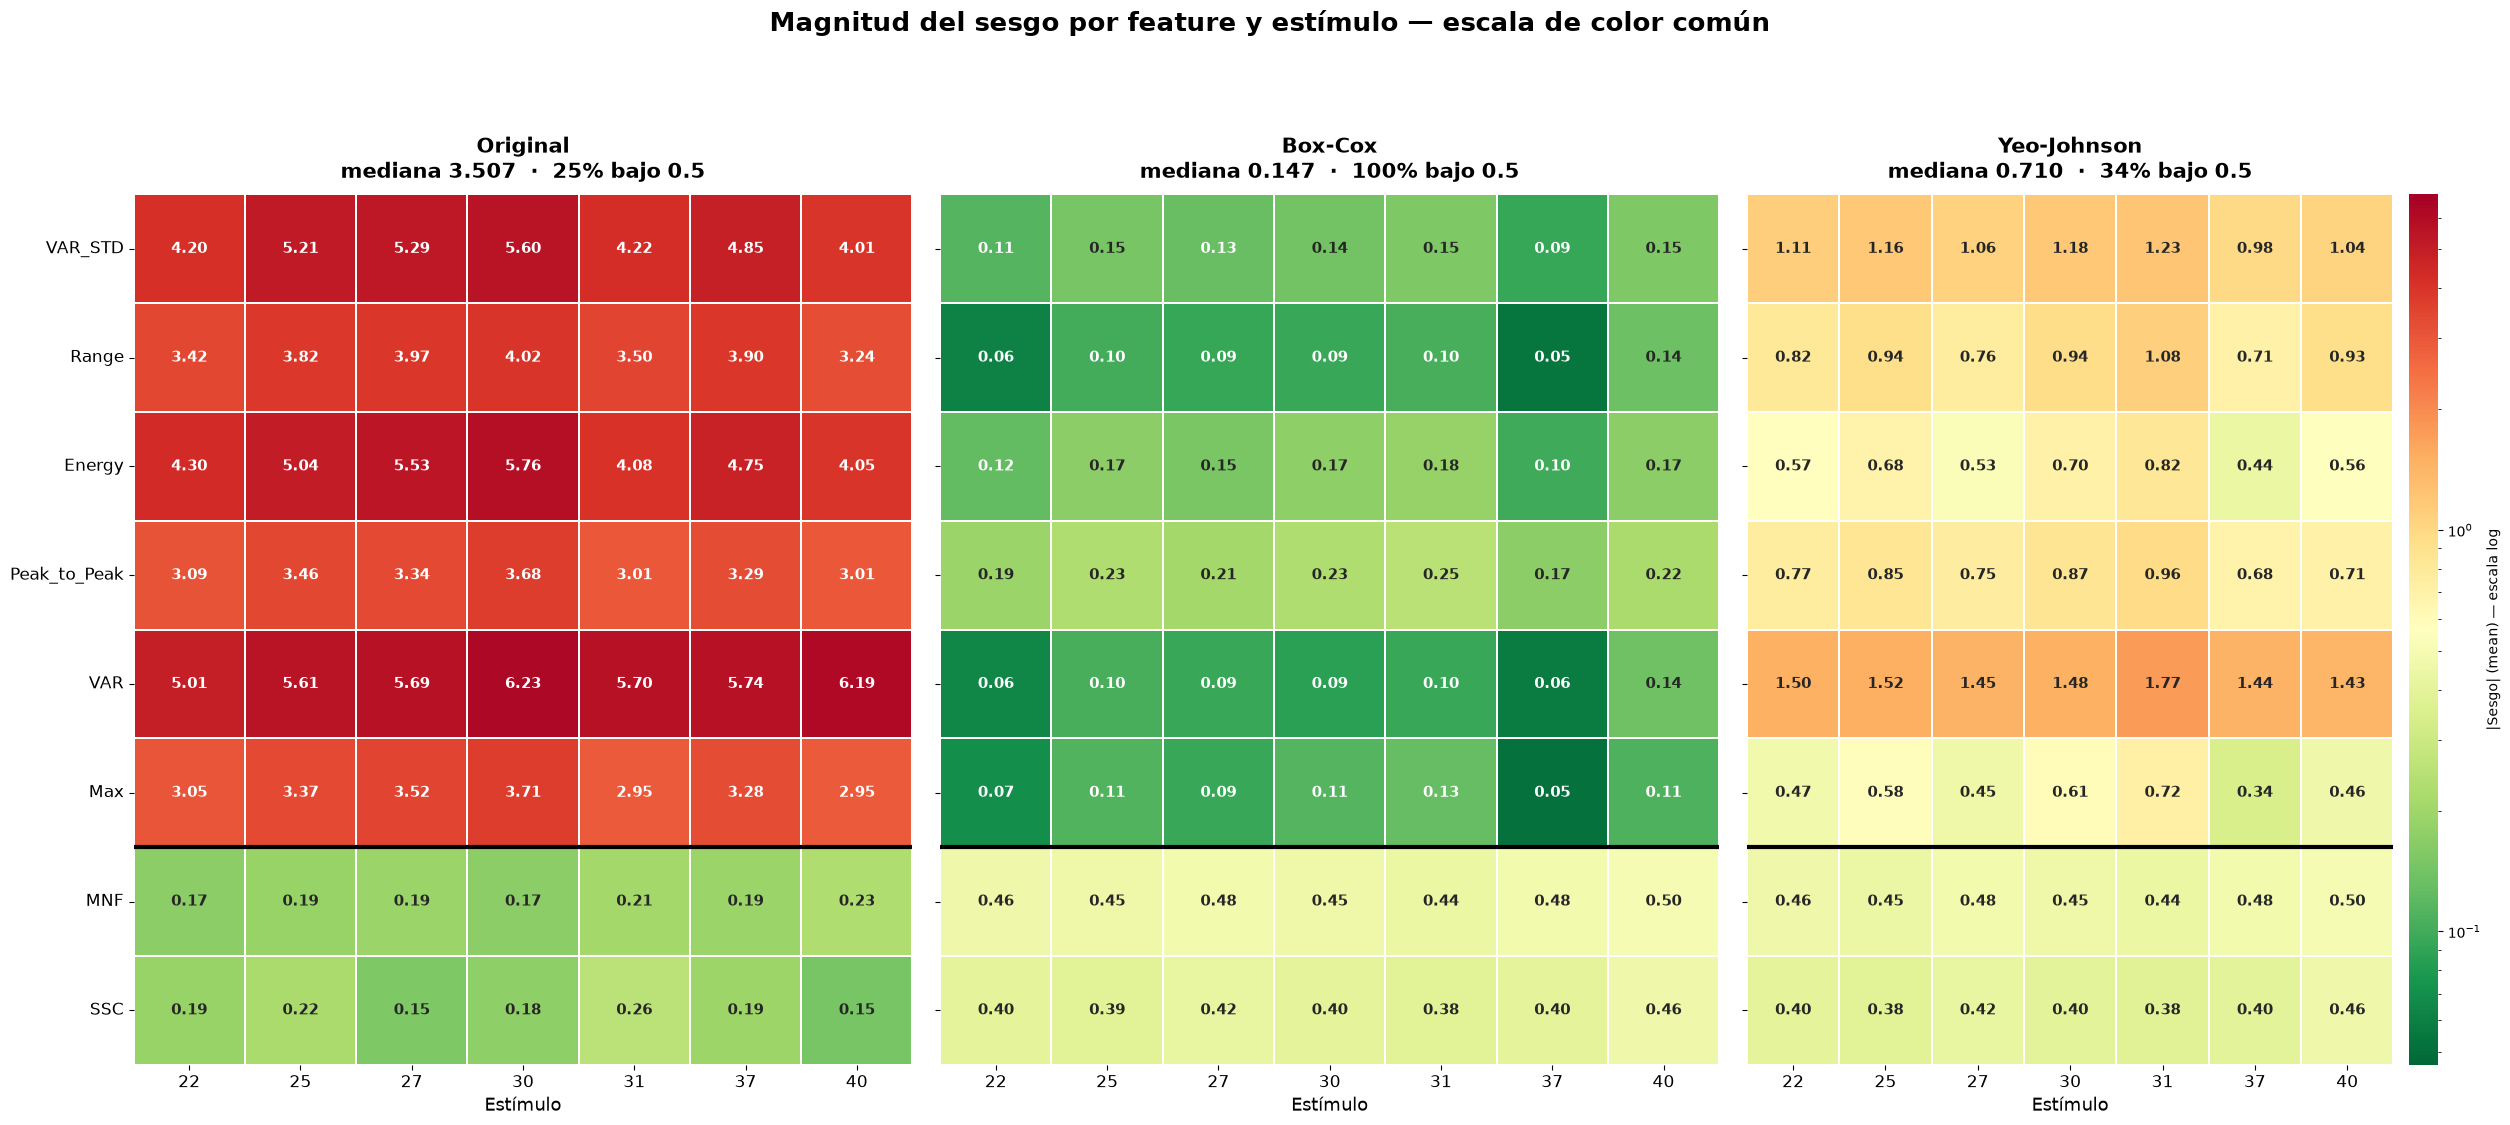

In [ ]:
pivots = heatmap_sesgo(df_comparacion, FEATURES)

In [113]:
from matplotlib.colors import LogNorm

def heatmap_sesgo(df_comparacion, features=None, agg='median',
                  modo='norm_global', vmin=None, vmax=None, umbral=0.5,
                  separar=('MNF','SSC'), cmap='RdYlGn_r', figsize=None):
    """
    modo : 'log'         -> escala de color logarítmica sobre |sesgo| crudo.
           'norm_global' -> divide los tres paneles por el MISMO máximo (0-1).
                            Mantiene comparabilidad entre paneles.
           'norm_panel'  -> cada panel dividido por su propio máximo (0-1).
                            NO comparable entre paneles — solo muestra el
                            patrón interno de cada transformación.
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    if features is not None:
        d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]

    feats = list(features) if features is not None else sorted(set(d.Feature))
    abajo  = [f for f in feats if f in (separar or ())]
    arriba = [f for f in feats if f not in abajo]
    feats  = arriba + abajo

    crudos = {t: d[d.transformacion == t]
                 .pivot_table(index='Feature', columns='stimulus',
                              values='abs', aggfunc=agg).reindex(feats)
              for t in orden}

    ref_global = float(max(np.nanmax(p.to_numpy()) for p in crudos.values()))

    if modo == 'norm_global':
        pivots = {t: p / ref_global for t, p in crudos.items()}
        refs   = {t: ref_global for t in orden}
        etiq, fmt, norm = f'|Sesgo| / {ref_global:.2f}  (máximo global)', '.3f', None
        vmin, vmax = 0, 1
    elif modo == 'norm_panel':
        refs   = {t: float(np.nanmax(p.to_numpy())) for t, p in crudos.items()}
        pivots = {t: p / refs[t] for t, p in crudos.items()}
        etiq, fmt, norm = '|Sesgo| / máximo del panel', '.3f', None
        vmin, vmax = 0, 1
    else:
        pivots, refs = crudos, {t: None for t in orden}
        todos = np.concatenate([p.to_numpy().ravel() for p in pivots.values()])
        todos = todos[np.isfinite(todos) & (todos > 0)]
        vmin = vmin or todos.min()*.9
        vmax = vmax or todos.max()*1.1
        norm = LogNorm(vmin=vmin, vmax=vmax)
        etiq, fmt = f'|Sesgo| ({agg}) — escala log', '.2f'

    figsize = figsize or (8.5*len(orden), 1.0*len(feats) + 3.4)
    fig, axes = plt.subplots(1, len(orden), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, t in zip(axes, orden):
        p, crudo = pivots[t], crudos[t]
        sns.heatmap(p, ax=ax, cmap=cmap, norm=norm,
                    vmin=None if norm else vmin, vmax=None if norm else vmax,
                    annot=True, fmt=fmt, annot_kws={'size':11,'weight':'bold'},
                    linewidths=1.2, linecolor='white', cbar=(ax is axes[-1]),
                    cbar_kws={'label':etiq,'pad':.02,'aspect':30}
                              if ax is axes[-1] else None)
        if abajo:
            ax.axhline(len(arriba), color='black', lw=3)

        med    = np.nanmedian(crudo.to_numpy())
        pct_ok = np.nanmean(crudo.to_numpy() < umbral) * 100
        extra  = (f'  ·  máx {refs[t]:.2f}' if modo == 'norm_panel' else '')
        ax.set_title(t, fontweight='bold', fontsize=16, pad=12)
        ax.set_xlabel('Estímulo', fontsize=13); ax.set_ylabel('')
        ax.tick_params(axis='y', rotation=0, labelsize=12)
        ax.tick_params(axis='x', labelsize=12)

    aviso = ('  ⚠ escala propia por panel — NO comparable entre paneles'
             if modo == 'norm_panel' else '')
    fig.suptitle(f'Magnitud del sesgo por feature y estímulo [{modo}]{aviso}',
                 fontsize=18, fontweight='bold', y=1.0)
    fig.tight_layout(rect=[0,0,1,.94], w_pad=2.0); plt.show()

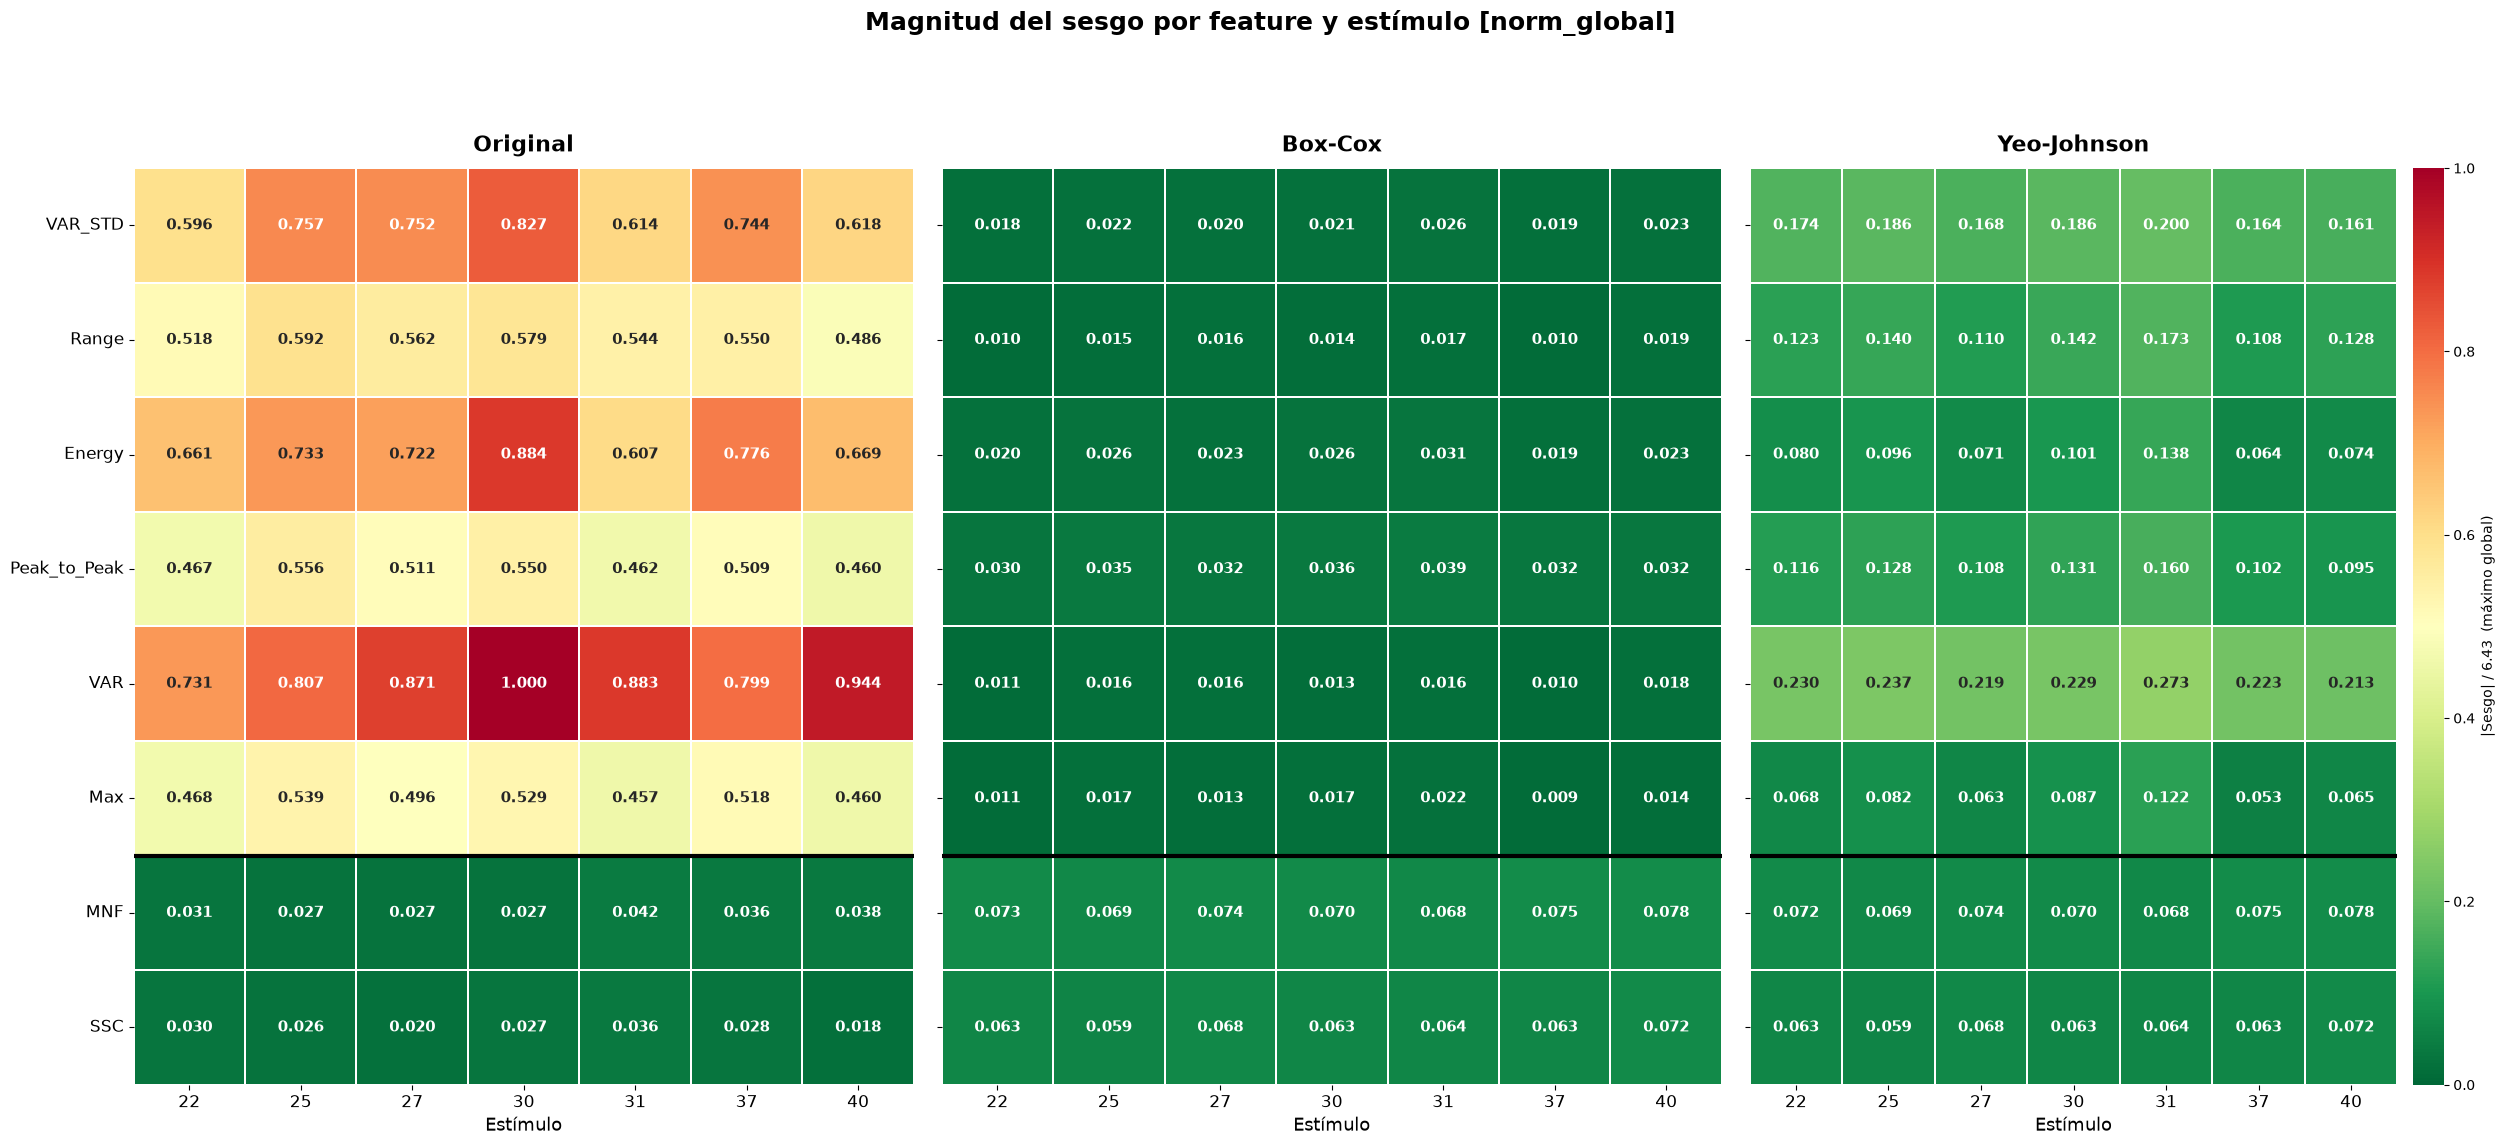

In [114]:
heatmap_sesgo(df_comparacion, FEATURES, modo='norm_global')

In [102]:
def boxplot_sesgo_por_transformacion(df_comparacion, features=None,
                                     umbral=0.5, normalizar=True, figsize=None):
    """
    Un panel por transformación. normalizar=True divide cada panel por su
    propio máximo → eje 0-1 en los tres.
    OJO: los paneles NO son comparables en magnitud entre sí; muestran la
    forma relativa dentro de cada transformación.
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    if features is not None:
        d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]
    colors = {'Original':'#999999','Box-Cox':'#3d5a99','Yeo-Johnson':'#4f9367'}

    figsize = figsize or (8.5*len(orden), 6)
    fig, axes = plt.subplots(1, len(orden), figsize=figsize,
                             sharey=normalizar)
    axes = np.atleast_1d(axes)

    for ax, t in zip(axes, orden):
        sub = d[d.transformacion == t].copy()
        ref = float(sub['abs'].max())
        sub['_y'] = sub['abs'] / ref if normalizar else sub['abs']
        umb = umbral / ref if normalizar else umbral

        sns.boxplot(data=sub, x='stimulus', y='_y', ax=ax, color=colors[t],
                    showfliers=False, width=.65,
                    medianprops=dict(color='black', linewidth=2))

        if 0 < umb < (1.02 if normalizar else sub['_y'].max()*1.05):
            ax.axhline(umb, color='darkorange', ls=':', lw=2, zorder=0)
            ax.text(.985, umb, f'  |sesgo| = {umbral}', transform=ax.get_yaxis_transform(),
                    ha='right', va='bottom', fontsize=10, color='darkorange')

        if normalizar:
            ax.set_ylim(0, 1.04)
            ax.set_title(f'{t}\nmáx = {ref:.2f}', fontweight='bold', fontsize=15, pad=10)
        else:
            ax.set_title(t, fontweight='bold', fontsize=16, pad=12)

        ax.set_xlabel('Estímulo', fontsize=13)
        ax.set_ylabel(('|Sesgo| / máx del panel' if normalizar else '|Sesgo|')
                      if ax is axes[0] else '', fontsize=13)
        ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
        for s in ('top','right'): ax.spines[s].set_visible(False)
        ax.tick_params(labelsize=12)

    fig.tight_layout(w_pad=2.5); plt.show()

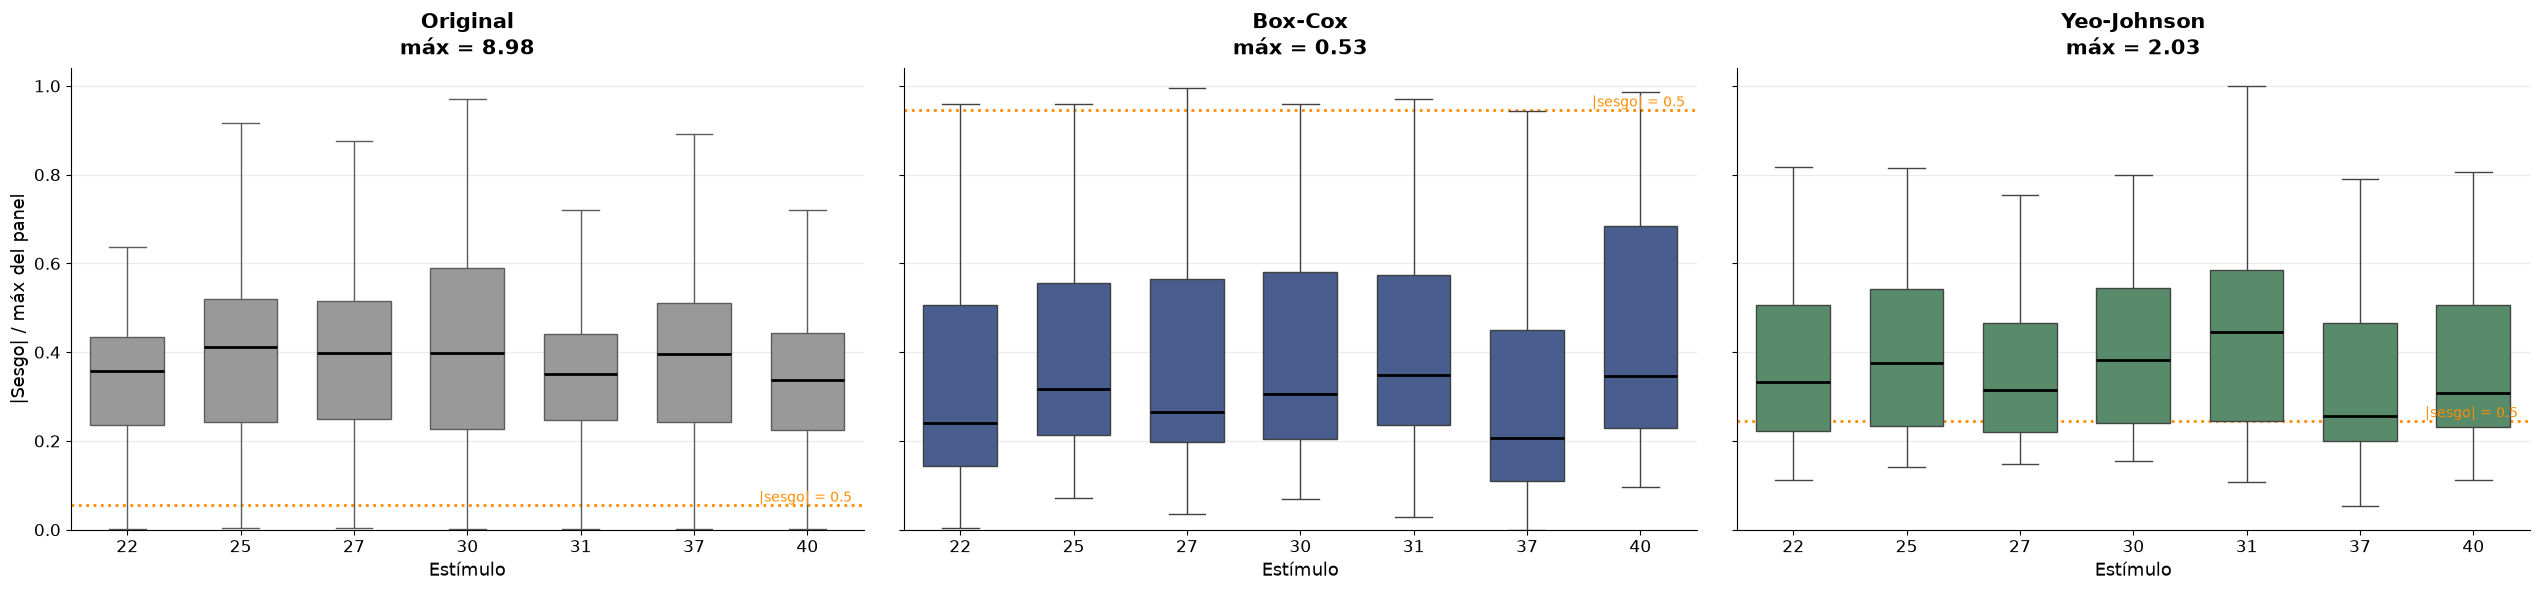

In [103]:
boxplot_sesgo_por_transformacion(df_comparacion, FEATURES)

In [106]:
def boxplot_sesgo_unificado(df_comparacion, features=None, umbral=0.5,
                            figsize=(16, 7)):
    """
    Los tres en un solo panel. Cada transformación normalizada por SU máximo,
    así ninguna aplasta a las otras. Eje 0-1.
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    if features is not None:
        d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]
    colors = {'Original':'#999999','Box-Cox':'#3d5a99','Yeo-Johnson':'#4f9367'}

    refs = {t: float(d.loc[d.transformacion == t, 'abs'].max()) for t in orden}
    d['_y'] = d['abs'] / d['transformacion'].map(refs)

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=d, x='stimulus', y='_y', hue='transformacion',
                hue_order=orden, palette=colors, ax=ax,
                showfliers=False, width=.78,
                medianprops=dict(color='black', linewidth=1.8))

    for t in orden:                       # umbral: uno por transformación
        u = umbral / refs[t]
        if u < 1.02:
            ax.axhline(u, color=colors[t], ls=':', lw=2, alpha=.9, zorder=0)
            ax.text(1.002, u, f' {umbral}', transform=ax.get_yaxis_transform(),
                    va='center', fontsize=9, color=colors[t], fontweight='bold')

    ax.set_ylim(0, 1.04)
    ax.set_xlabel('Estímulo', fontsize=14)
    ax.set_ylabel('|Sesgo| normalizado por el máximo de su transformación', fontsize=13)
    ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
    for s in ('top','right'): ax.spines[s].set_visible(False)
    ax.tick_params(labelsize=12)

    etiquetas = [f'{t}  (máx {refs[t]:.2f})' for t in orden]
    ax.legend(handles=[Patch(facecolor=colors[t], label=e)
                       for t, e in zip(orden, etiquetas)],
              loc='upper center', bbox_to_anchor=(.5, 1.13), ncol=len(orden),
              fontsize=13, frameon=False)
    fig.tight_layout(); plt.show()

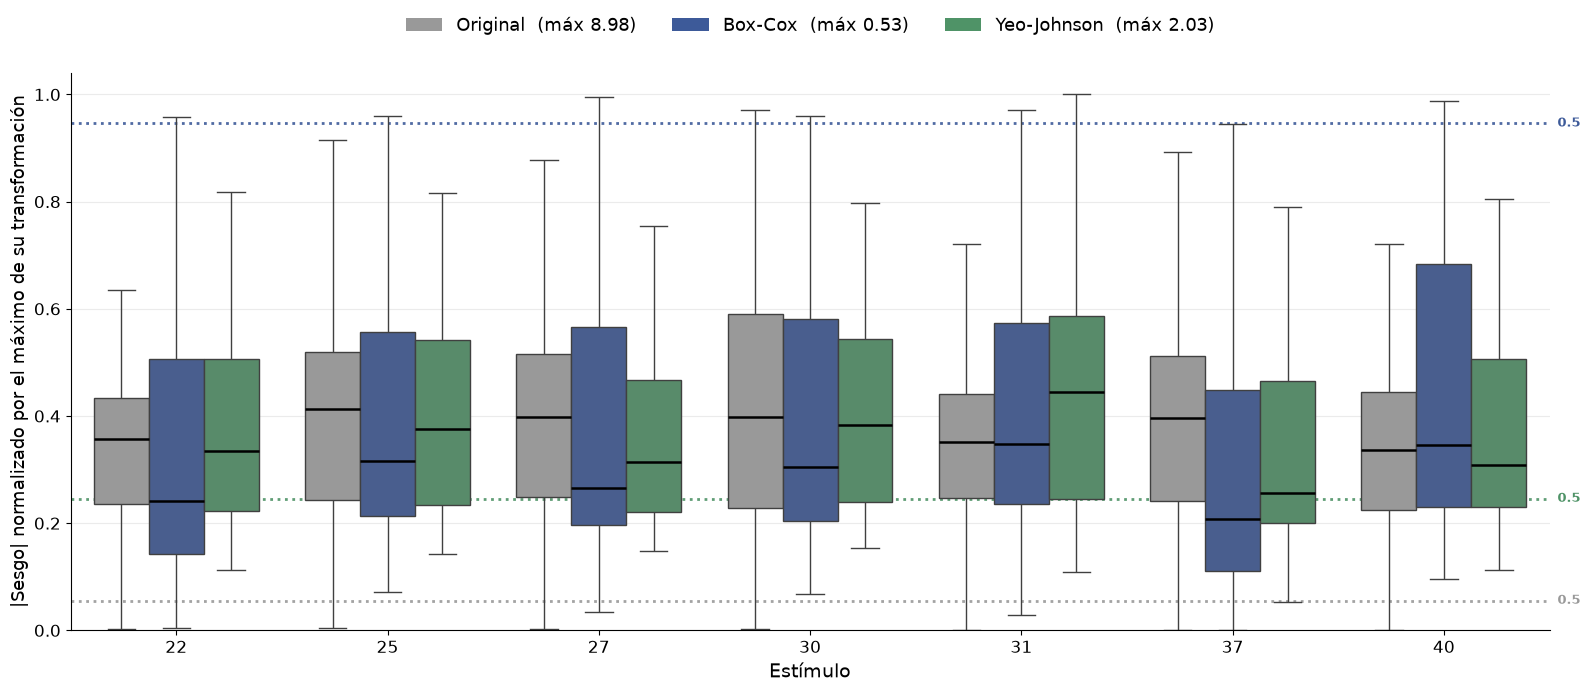

In [108]:
boxplot_sesgo_unificado(df_comparacion, FEATURES)

In [111]:
def boxplot_sesgo_por_feature(df_comparacion, features, umbral=0.5,
                              ncols=4, norm_por='feature', figsize=None):
    """
    Un panel por feature; dentro, las 3 transformaciones normalizadas
    por su máximo → eje 0-1 en todos los paneles.

    norm_por : 'feature' -> el máximo se calcula por transformación DENTRO
                            de cada feature (cada panel se aprovecha al máximo).
               'global'  -> un solo máximo por transformación para toda la
                            figura (paneles comparables entre sí).
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]
    colors = {'Original':'#999999','Box-Cox':'#3d5a99','Yeo-Johnson':'#4f9367'}

    if norm_por == 'global':
        g = {t: float(d.loc[d.transformacion == t, 'abs'].max()) for t in orden}
        refs = {(f, t): g[t] for f in features for t in orden}
    else:
        refs = {(f, t): float(d.loc[(d.Feature == f) &
                                    (d.transformacion == t), 'abs'].max())
                for f in features for t in orden}

    d['_ref'] = [refs.get((f, t), np.nan)
                 for f, t in zip(d.Feature, d.transformacion)]
    d['_y'] = d['abs'] / d['_ref']

    nrows = int(np.ceil(len(features)/ncols))
    figsize = figsize or (6.0*ncols, 4.8*nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(data=d[d.Feature == feat], x='stimulus', y='_y',
                    hue='transformacion', hue_order=orden, palette=colors,
                    ax=ax, showfliers=False, width=.78,
                    medianprops=dict(color='black', linewidth=1.5))

        for t in orden:                      # umbral por transformación
            r = refs.get((feat, t))
            if r and umbral/r < 1.02:
                ax.axhline(umbral/r, color=colors[t], ls=':', lw=1.7,
                           alpha=.9, zorder=0)

        ax.set_title(feat, fontweight='bold', fontsize=14, pad=8)
        ax.set_ylim(0, 1.04)
        ax.set_xlabel('Estímulo' if i >= len(features)-ncols else '', fontsize=11)
        ax.set_ylabel('|Sesgo| / máx' if i % ncols == 0 else '', fontsize=12)
        ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
        for s in ('top','right'): ax.spines[s].set_visible(False)
        if ax.get_legend(): ax.get_legend().remove()
        ax.tick_params(labelsize=10)

    for ax in axes[len(features):]: ax.set_visible(False)

    fig.legend(handles=[Patch(facecolor=colors[t], label=t) for t in orden],
               loc='upper center', bbox_to_anchor=(.5, .975), ncol=len(orden),
               fontsize=14, frameon=False)
    fig.suptitle('Sesgo por estímulo y feature — cada transformación normalizada por su máximo',
                 fontsize=18, fontweight='bold', y=1.0)
    fig.tight_layout(rect=[0,0,1,.945], h_pad=2.4, w_pad=1.2); plt.show()

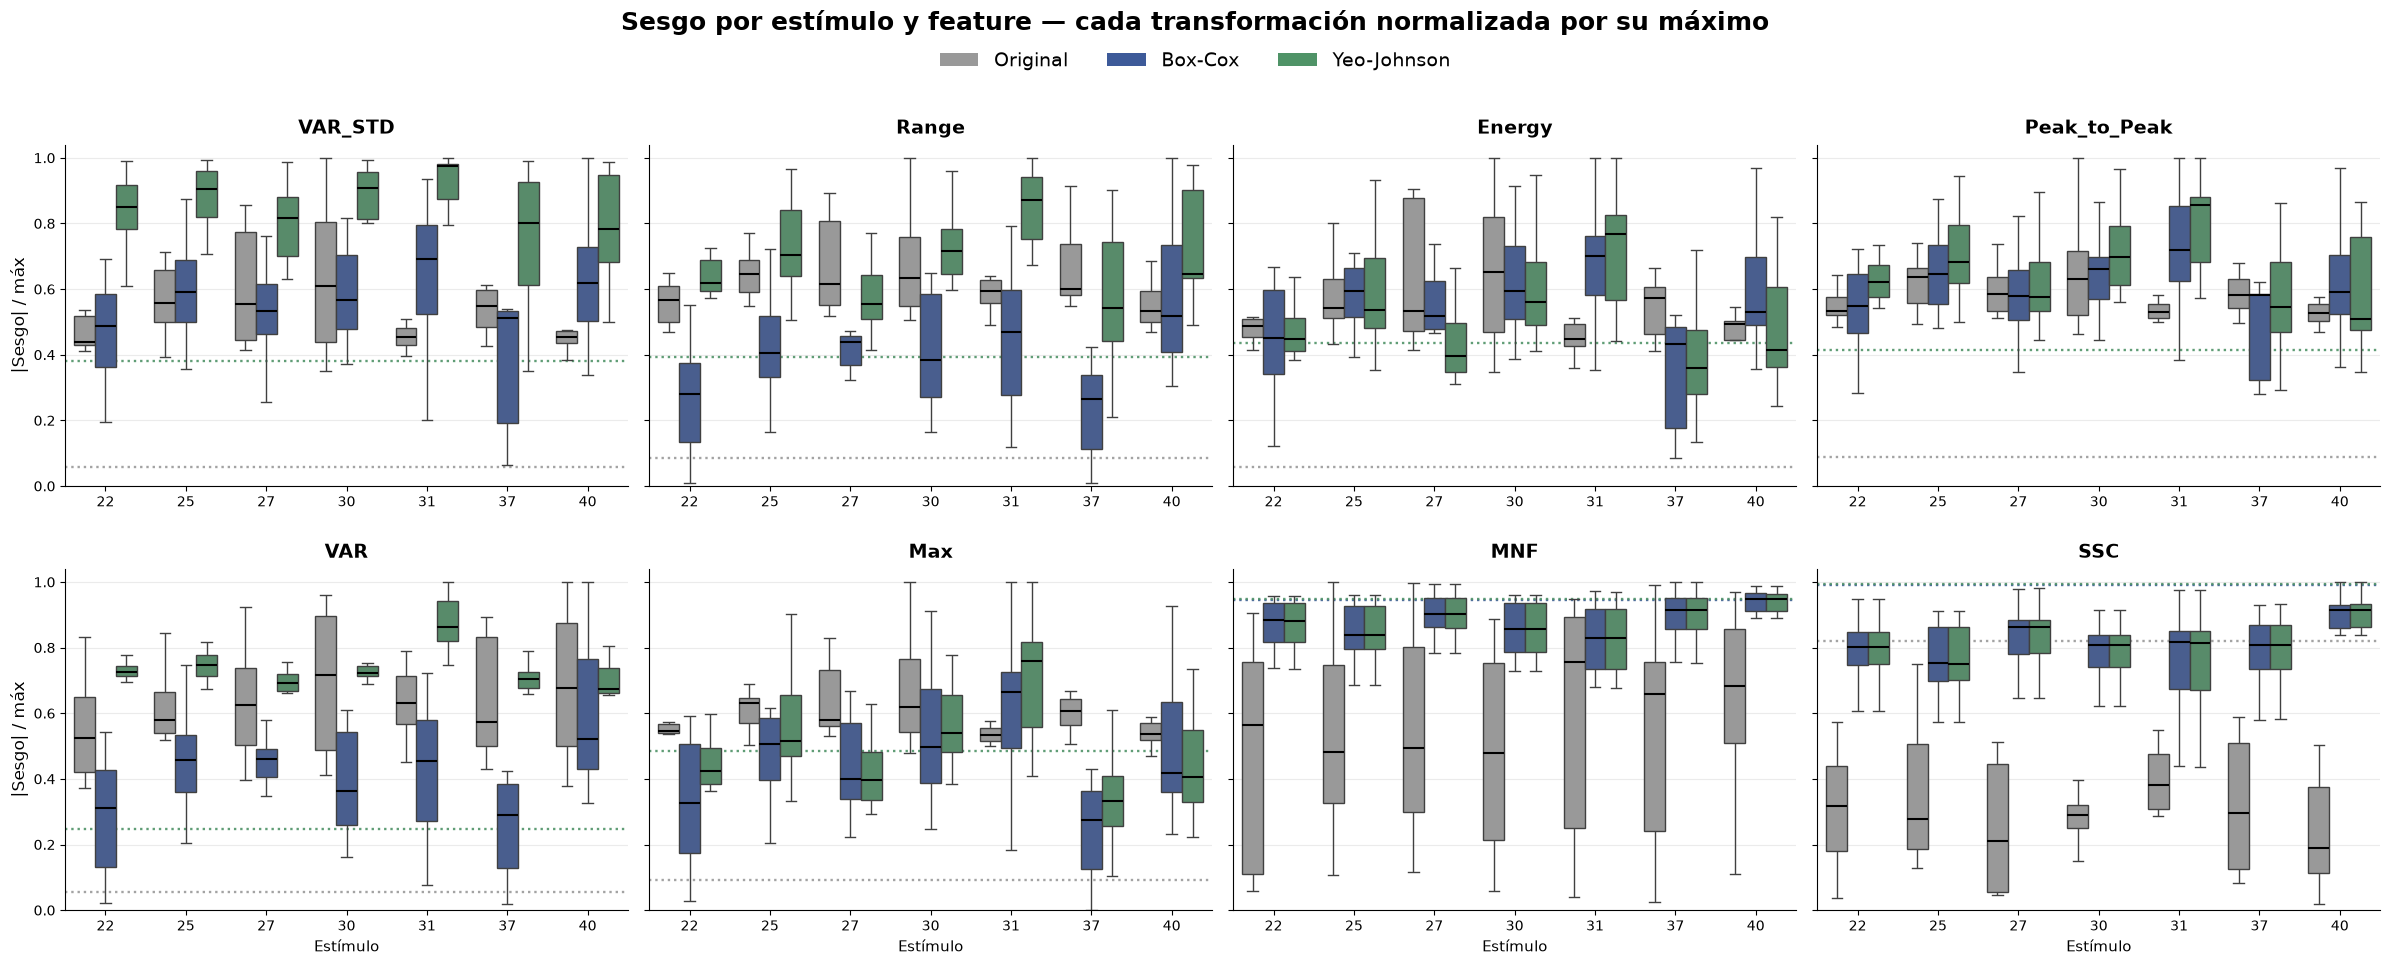

In [112]:
boxplot_sesgo_por_feature(df_comparacion, FEATURES)

In [81]:
def barras_reduccion(df_comparacion, features=None, n_channels=8,
                     umbral_orig=0.3, ylim=(0, 105), agg='median',
                     grid=(4, 2), figsize=None, ocultar_vacios=True):
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()

    key = ['Feature','stimulus','Channel']
    base = d[d.transformacion=='Original'].set_index(key)['abs']
    d['base'] = pd.MultiIndex.from_frame(d[key]).map(base).to_numpy()

    excluidos = sorted(d.loc[d['base'] < umbral_orig, 'Feature'].unique())
    d = d[(d['base'] >= umbral_orig) & (d.transformacion != 'Original')]
    d['reduccion'] = (1 - d['abs']/d['base']) * 100

    feats = [f for f in (features or sorted(d.Feature.unique()))
             if f in set(d.Feature)]          # <- quita columnas vacías
    if excluidos:
        print(f'Excluidos (|sesgo original| < {umbral_orig}): {", ".join(excluidos)}')

    colors = {'Box-Cox':'#3d5a99','Yeo-Johnson':'#4f9367'}
    nrows, ncols = grid
    figsize = figsize or (11*ncols, 4.6*nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             sharey=True, sharex=True)
    axes = np.atleast_1d(axes).flatten()

    x = np.arange(len(feats)); width = .40

    for ch, ax in zip(range(1, n_channels+1), axes):
        sub = d[d.Channel == ch]
        for j, t in enumerate(['Box-Cox','Yeo-Johnson']):
            vals = [sub.loc[(sub.Feature==f) & (sub.transformacion==t),
                            'reduccion'].agg(agg) for f in feats]
            b = ax.bar(x + (j-.5)*width, vals, width*.92,
                       color=colors[t], edgecolor='white', linewidth=1.2, zorder=3)
            ax.bar_label(b, fmt='%.0f', fontsize=10, padding=3,
                         fontweight='bold', color='#333')

        ax.set_ylim(ylim)
        ax.set_yticks(range(0, 101, 20))
        ax.set_xticks(x)
        ax.set_xticklabels(feats, rotation=30, ha='right', fontsize=12)
        ax.set_title(f'Canal {ch}', fontweight='bold', fontsize=15, pad=10)
        ax.grid(axis='y', alpha=.25, zorder=0)
        ax.set_axisbelow(True)
        for lado in ('top','right'):
            ax.spines[lado].set_visible(False)
        ax.tick_params(labelsize=11)

    if ocultar_vacios:
        for ax in axes[n_channels:]:
            ax.set_visible(False)

    for i, ax in enumerate(axes[:n_channels]):
        if i % ncols == 0:
            ax.set_ylabel('% reducción del sesgo', fontsize=13)

    fig.legend(handles=[Patch(facecolor=c, label=t) for t, c in colors.items()],
               loc='upper center', bbox_to_anchor=(.5, .975), ncol=2,
               fontsize=15, frameon=False)
    fig.suptitle('Reducción del sesgo por canal y feature  (mayor = mejor)',
                 fontsize=20, fontweight='bold', y=1.005)
    fig.tight_layout(rect=[0, 0, 1, .955], h_pad=3.0, w_pad=2.5)
    plt.show()

Excluidos (|sesgo original| < 0.3): MNF, SSC


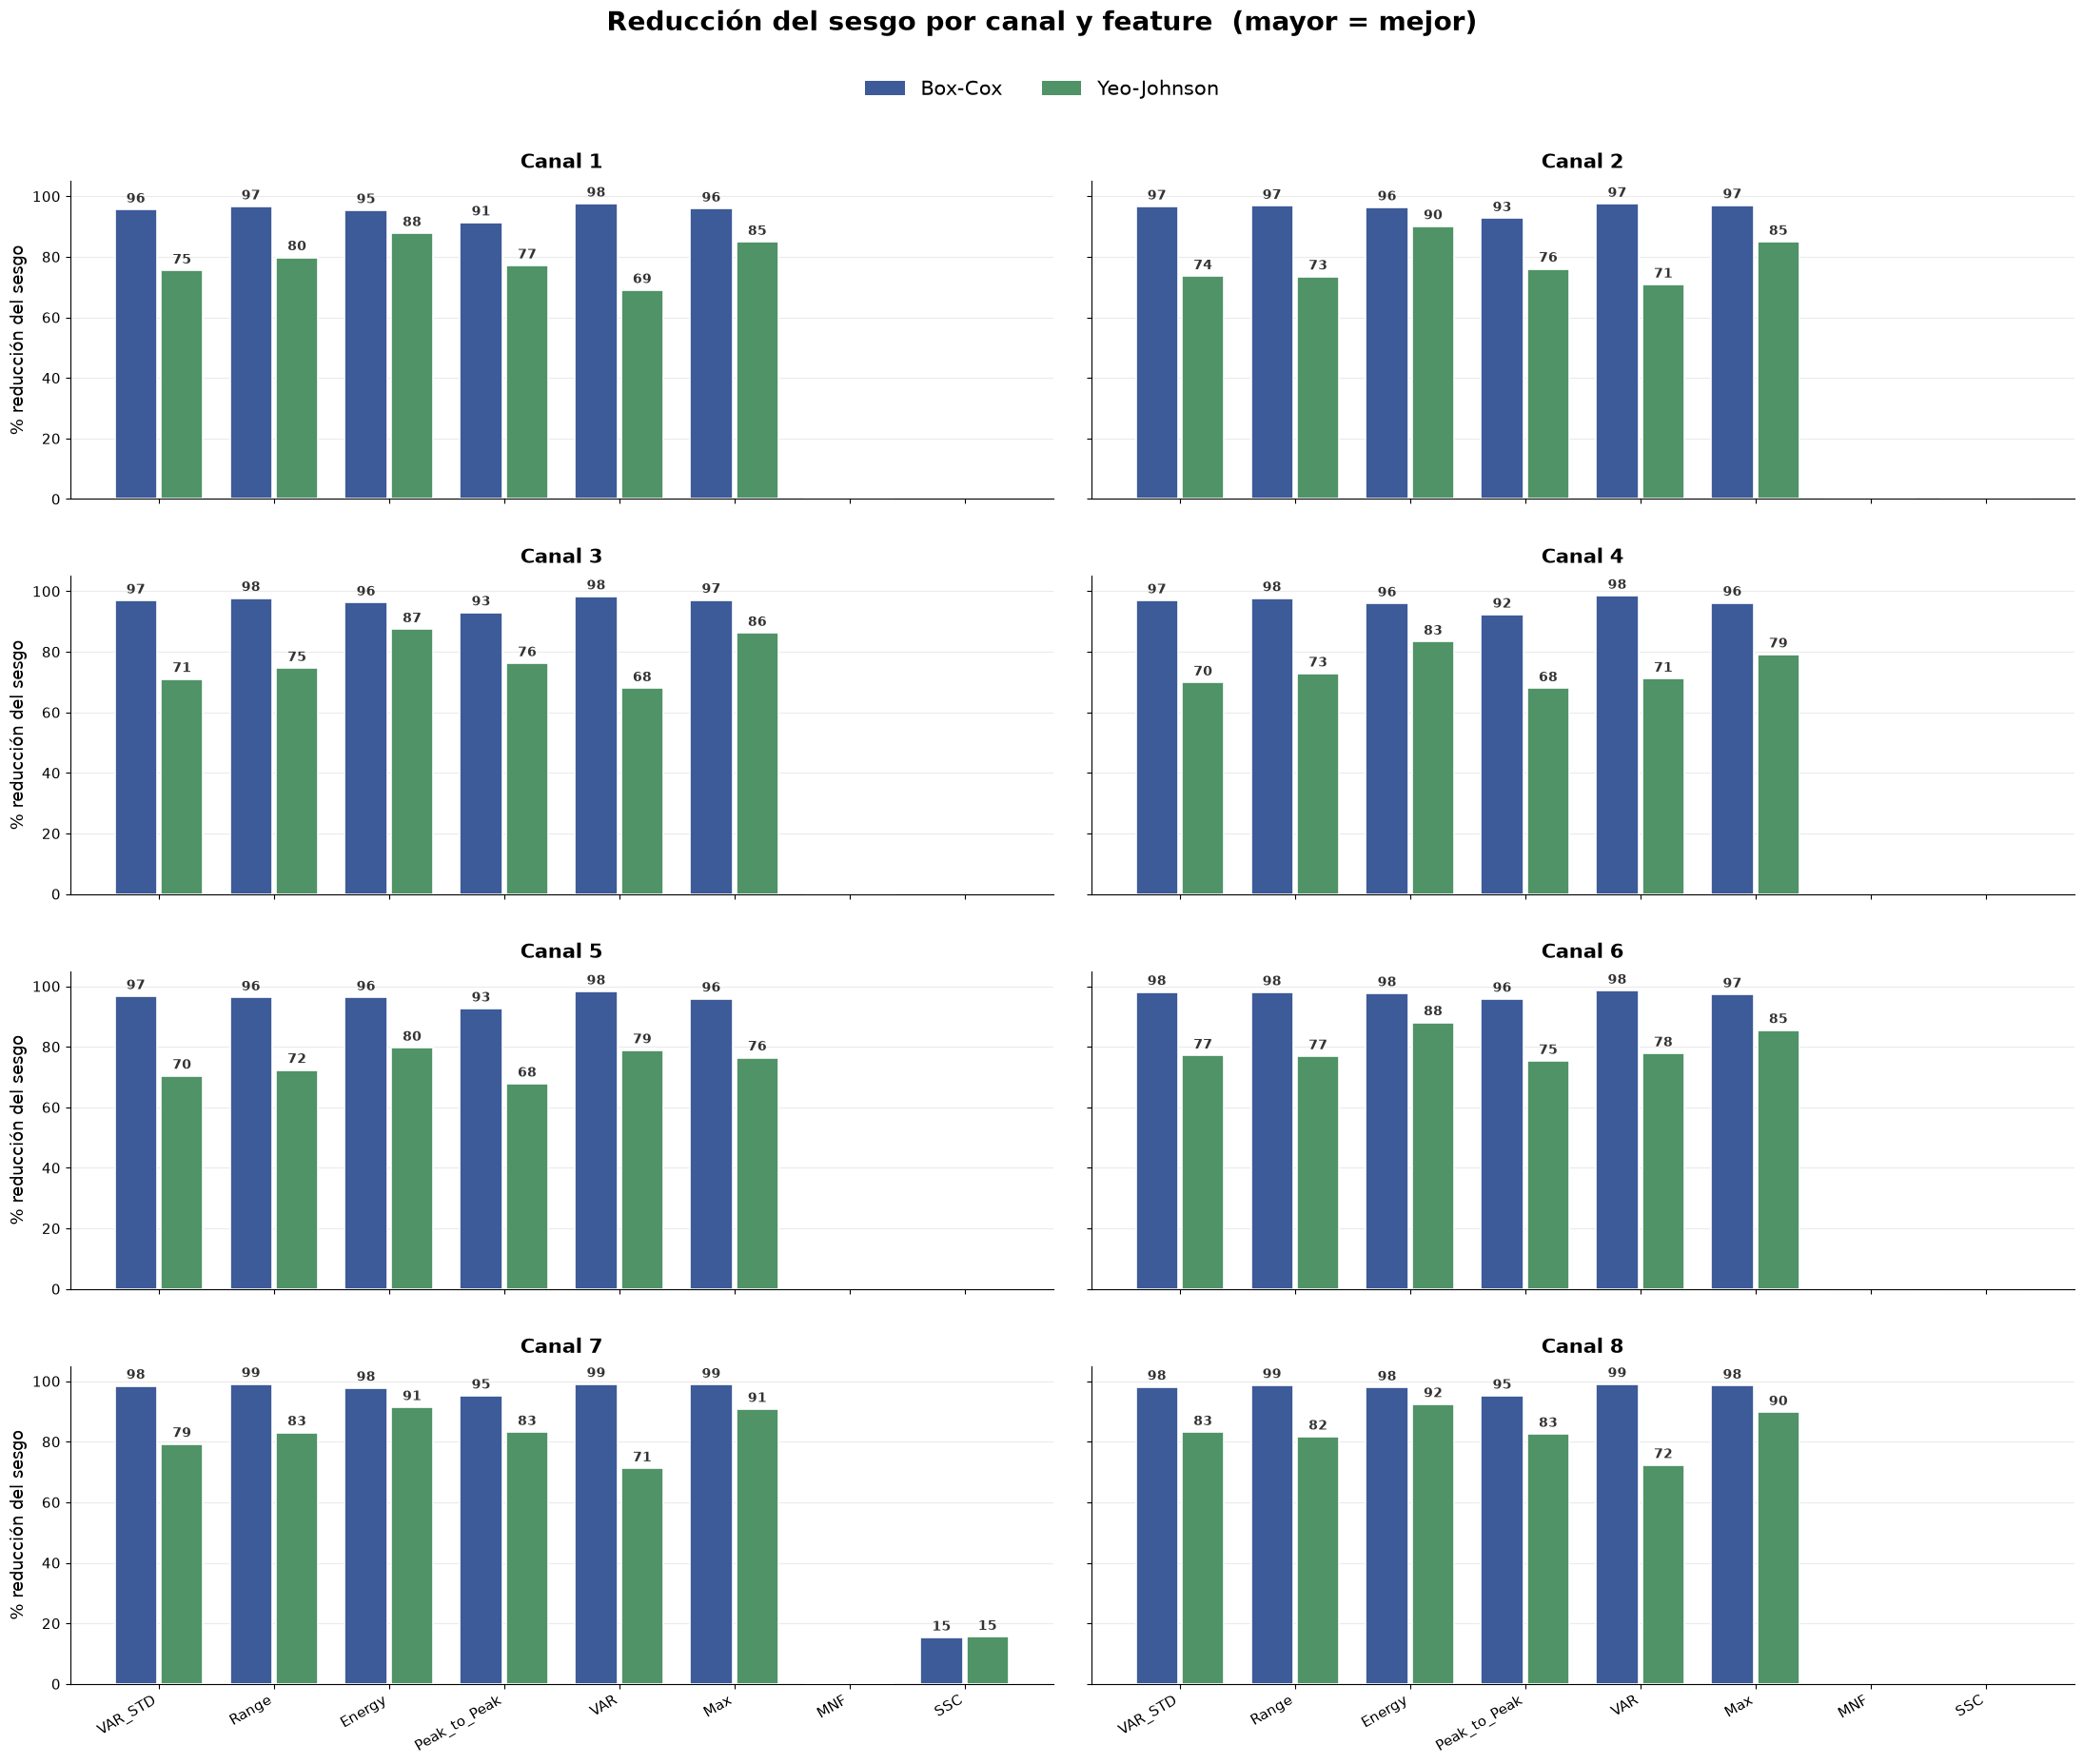

In [82]:
barras_reduccion(df_comparacion, FEATURES)